In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

from clustering import FeatureEngineer
import matplotlib.pyplot as plt
import seaborn as sns

# Set up style for matplotlib and seaborn
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")

In [2]:
# Load the cleaned UK data
data_path = '../data/processed/cleaned_uk_data.csv'

# Initialize feature engineer and load data
engineer = FeatureEngineer(data_path)
df = engineer.load_data()
df.head()

Size of data: (485123, 11)


d:\aio\customer-churn-prediction\notebooks\../src\clustering.py:139: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.data_path)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,HourOfDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,017850,United Kingdom,15.30,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,017850,United Kingdom,22.00,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,017850,United Kingdom,20.34,2,8


In [3]:
print(f"Number of features created: {len(engineer.feature_customer)}")
print("Features:")
for i, feature in enumerate(engineer.feature_customer, 1):
    print(f"{i:2d}. {feature}")

Number of features created: 16
Features:
 1. Sum_Quantity
 2. Mean_UnitPrice
 3. Mean_TotalPrice
 4. Sum_TotalPrice
 5. Count_Invoice
 6. Count_Stock
 7. Mean_InvoiceCountPerStock
 8. Mean_StockCountPerInvoice
 9. Mean_UnitPriceMeanPerInvoice
10. Mean_QuantitySumPerInvoice
11. Mean_TotalPriceMeanPerInvoice
12. Mean_TotalPriceSumPerInvoice
13. Mean_UnitPriceMeanPerStock
14. Mean_QuantitySumPerStock
15. Mean_TotalPriceMeanPerStock
16. Mean_TotalPriceSumPerStock


In [7]:
# customer-level features
customer_features = engineer.create_customer_features()
customer_features.head()

Calculating features for customer...
Finished calculating features


,CustomerID,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
0,000nan,405650.0,6.248856,13.125415,1716830.53,1373.0,3401.0,38.459865,95.267298,34.401125,295.447924,41.005373,1250.422819,10.903397,119.273743,14.841714,504.801685
1,012346,74215.0,1.040000,77183.600000,77183.60,1.0,1.0,1.000000,1.000000,1.040000,74215.000000,77183.600000,77183.600000,1.040000,74215.000000,77183.600000,77183.600000
2,012747,1275.0,4.367864,40.737961,4196.01,11.0,42.0,2.452381,9.363636,4.253949,115.909091,43.645453,381.455455,4.844583,30.357143,27.983690,99.905000
3,012748,25747.0,2.656279,7.338353,33719.73,209.0,1768.0,2.598982,21.985646,8.916506,123.191388,16.378101,161.338421,2.726409,14.562783,8.176556,19.072245
4,012749,1471.0,4.999950,20.557186,4090.88,5.0,160.0,1.243750,39.800000,5.095433,294.200000,21.871511,818.176000,4.785563,9.193750,20.025448,25.568000


In [8]:
# Hiển thị thông tin features đã tạo
print(f"Features have been created successfully:")
print(f"- Number of customer: {customer_features.shape[0]:,}")
print(f"- Number of features: {customer_features.shape[1] - 1}")

customer_features.set_index('CustomerID').describe().round(2)

Features have been created successfully:
- Number of customer: 3,921
- Number of features: 16


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
count,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00
mean,1189.08,4.46,71.74,2301.77,4.60,61.58,1.28,21.96,4.95,243.13,82.41,393.43,4.54,59.29,70.73,94.59
std,7463.77,35.96,1543.78,28391.37,23.01,97.54,0.80,20.14,36.85,1373.06,1840.84,1869.77,36.38,1277.18,1543.70,1665.21
min,1.00,0.12,2.10,3.75,1.00,1.00,1.00,1.00,0.12,1.00,2.10,3.45,0.12,1.00,2.14,2.23
25%,154.00,2.15,11.20,300.36,1.00,15.00,1.00,9.00,2.16,90.30,12.49,174.40,2.15,6.54,10.75,13.27
50%,365.00,2.85,17.28,652.74,2.00,35.00,1.10,16.77,2.91,156.67,17.84,281.62,2.87,11.22,17.06,19.40
75%,951.00,3.74,24.39,1578.67,5.00,77.00,1.32,28.00,3.85,262.00,26.76,409.61,3.71,17.89,23.43,30.45
max,405650.00,2033.10,77183.60,1716830.53,1373.00,3401.00,38.46,300.65,2033.10,74215.00,84235.52,84236.25,2033.10,74215.00,77183.60,77183.60


## Transform features

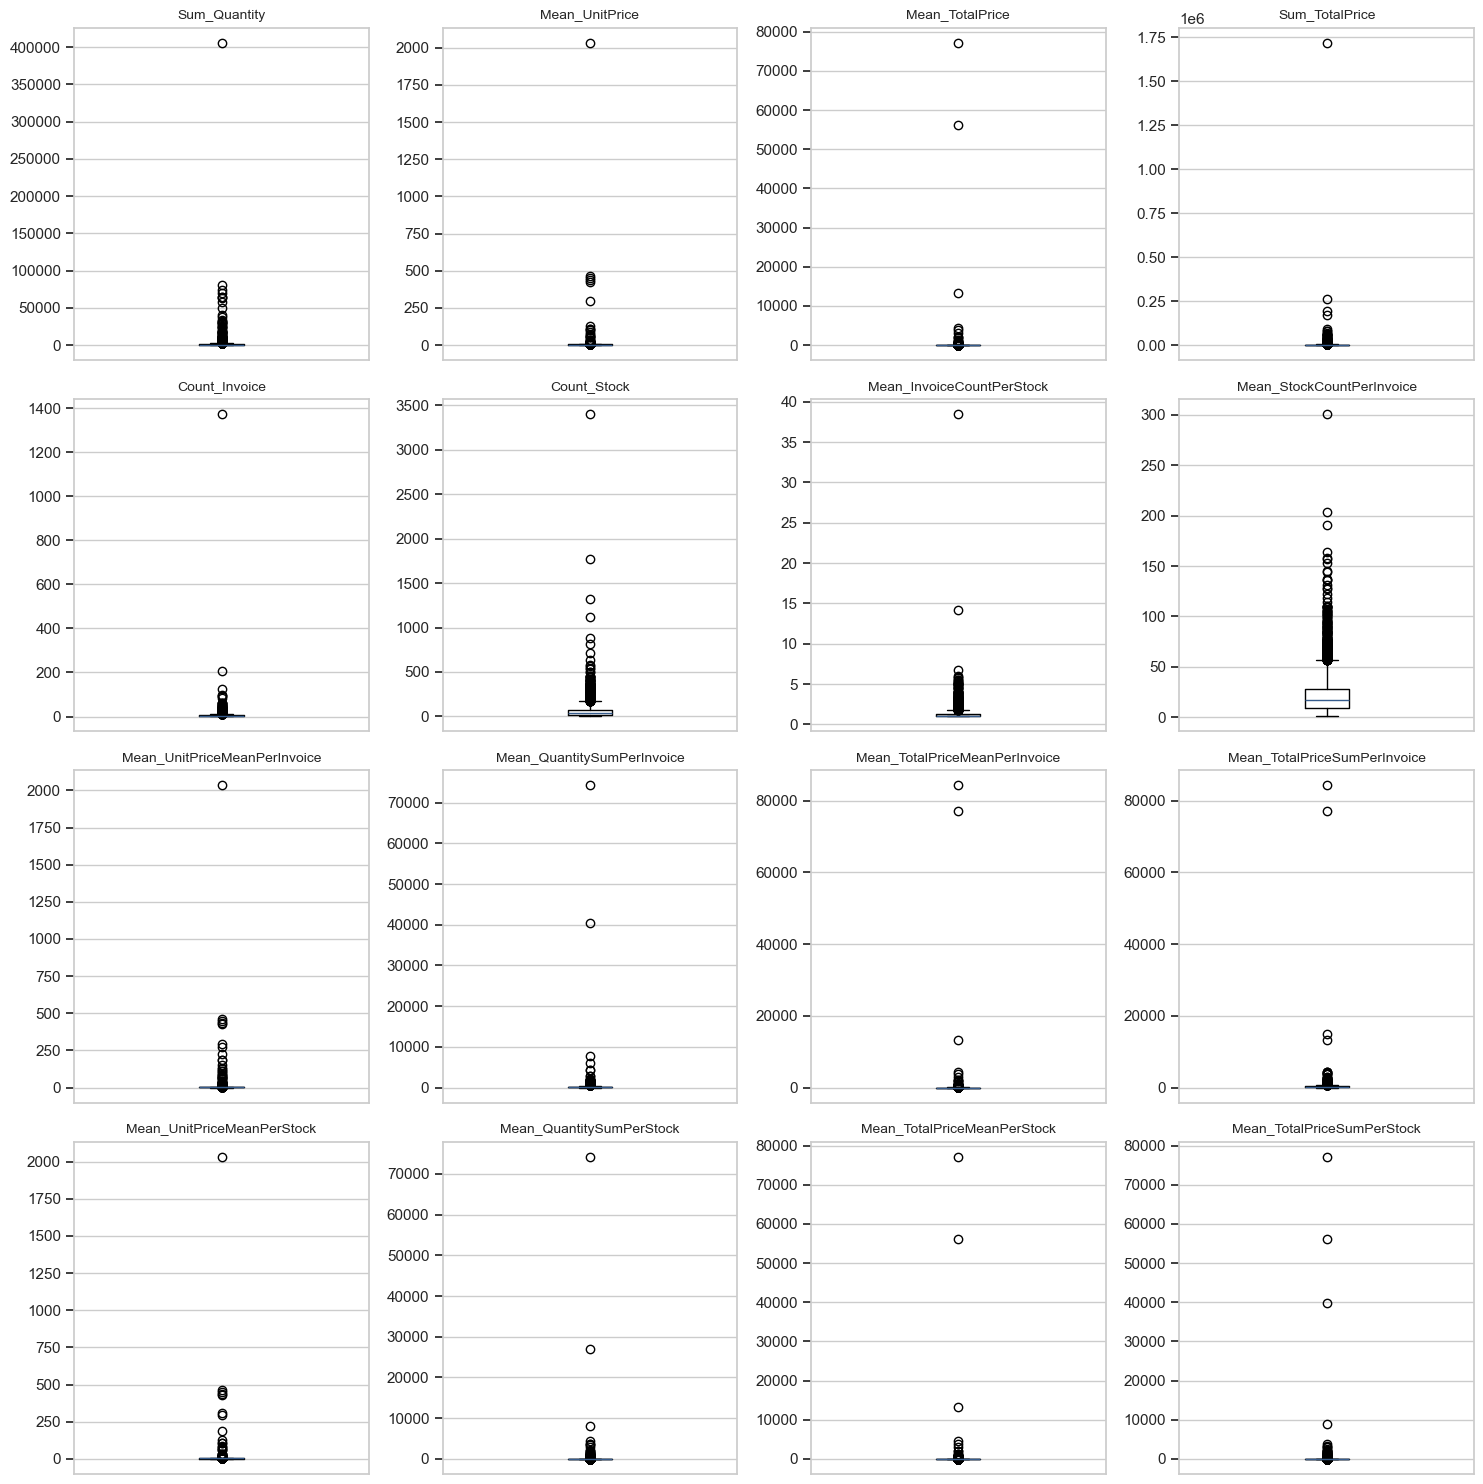

In [9]:
# Visualize features before Box-Cox transformation
engineer.plot_features_boxplots(transformed=False)

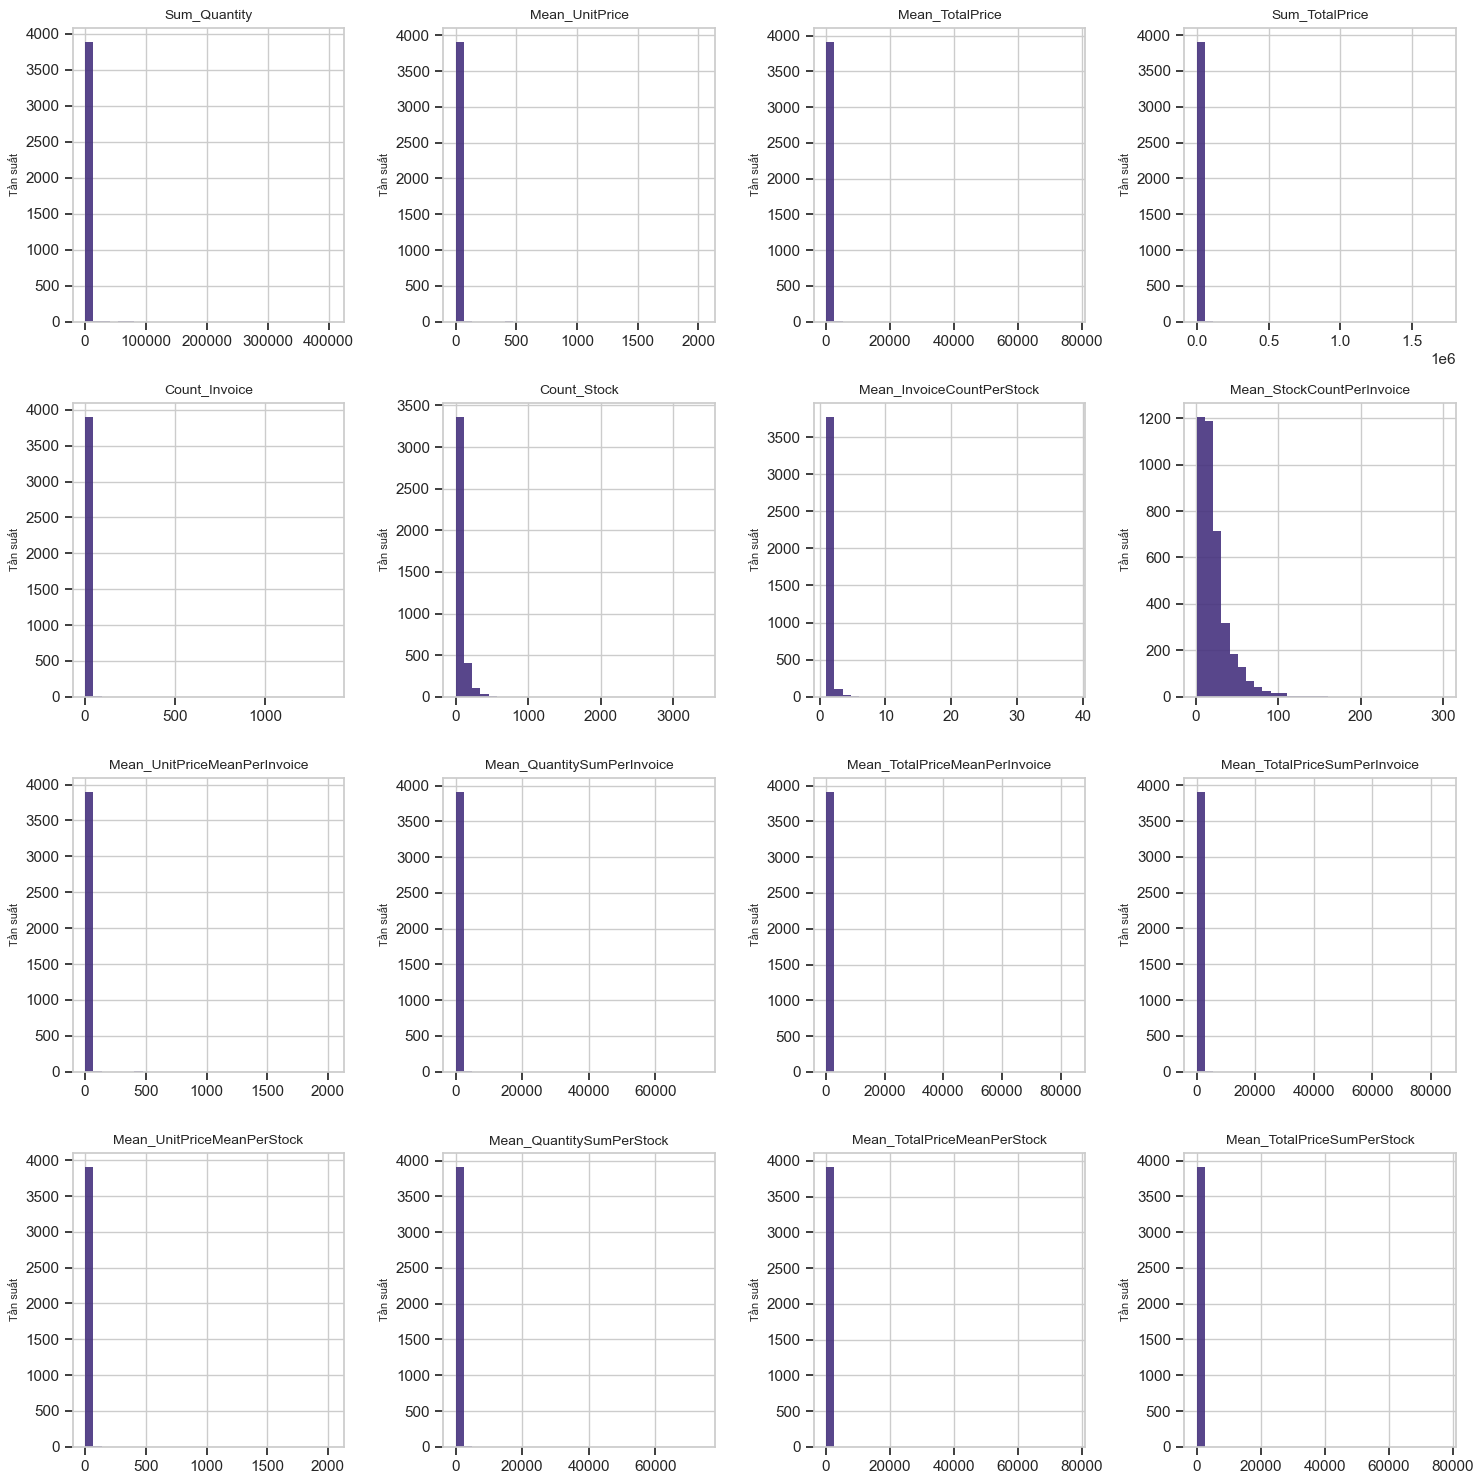

In [10]:
# Visualize by histograms
engineer.plot_features_histograms(transformed=False)

In [11]:
# Apply box-cox
customer_features_transformed = engineer.transform_features()
customer_features_transformed.head()

Applying Box-Cox transformation.
Box-Cox transformation has been done.


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
CustomerID,,,,,,,,,,,,,,,,
000nan,12.418279,1.154552,1.783960,8.054674,1.308770,11.165280,0.164071,6.206762,1.366120,7.068362,2.192765,6.566697,1.271492,2.331470,1.804801,2.531434
012346,10.840137,0.579166,3.032064,7.072794,0.538659,0.711290,0.161671,0.724852,0.568083,17.423099,3.072899,9.889452,0.577185,2.816569,2.926912,2.798045
012747,6.997907,1.055109,2.175213,5.864822,1.115795,4.338777,0.163985,2.726268,1.005987,5.701499,2.211284,5.550015,1.076986,2.007588,2.022440,2.287020
012748,9.848243,0.898647,1.538424,6.760862,1.291683,9.997861,0.164005,3.857781,1.178474,5.787455,1.880484,4.797239,0.901924,1.768302,1.566559,1.856004
012749,7.134646,1.094081,1.952969,5.852844,0.978016,6.172607,0.162880,4.747467,1.053063,7.061952,1.987163,6.206524,1.073548,1.592866,1.912260,1.949339


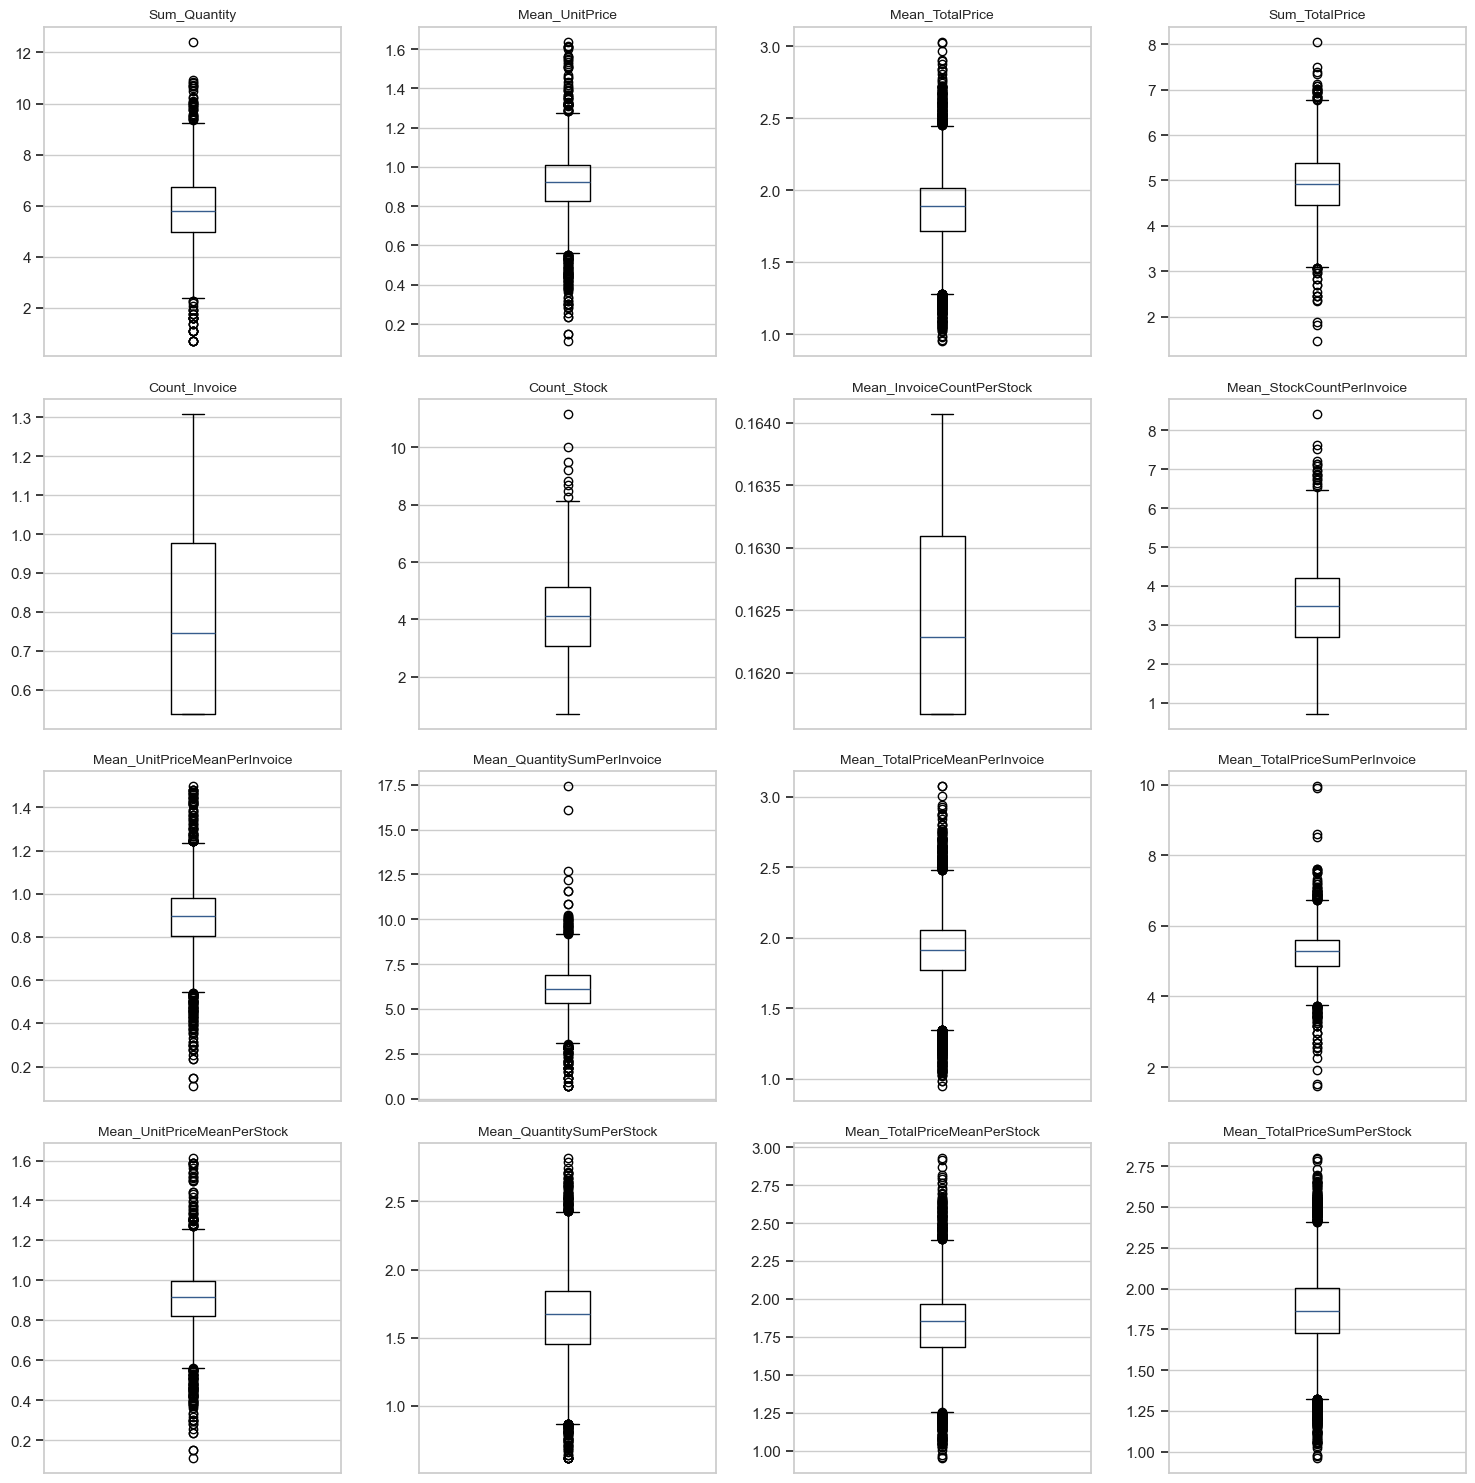

In [12]:
# Visualize features after Box-Cox transformation
engineer.plot_features_boxplots(transformed=True)

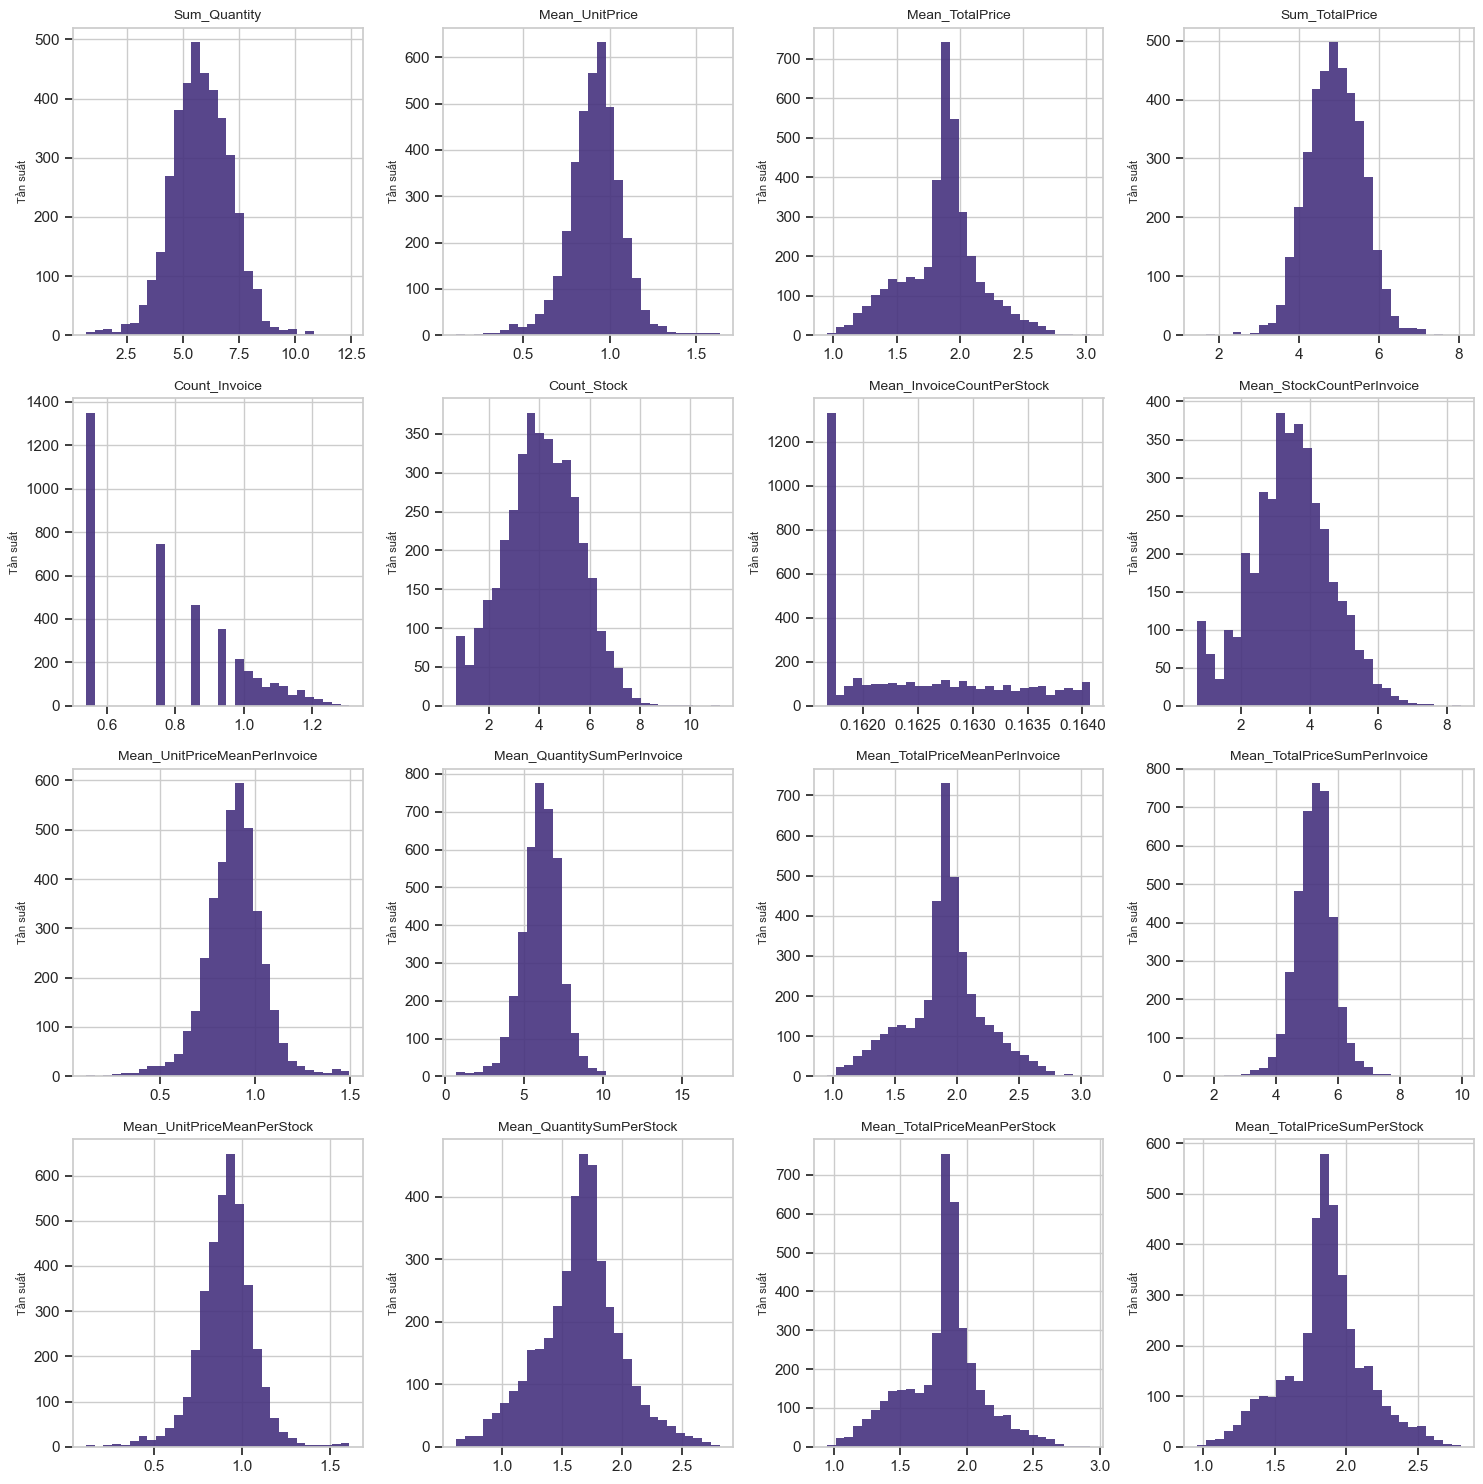

In [13]:
# Histograms visualization after box-cox
engineer.plot_features_histograms(transformed=True)

## Standardization

In [14]:
customer_features_scaled = engineer.scale_features()
print(f"Size of standardized features: {customer_features_scaled.shape}")
# display(customer_features_scaled.describe().round(2).loc[['mean', 'std']])
customer_features_scaled.head()

Feature scaling has been done.
Size of standardized features: (3921, 16)


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
CustomerID,,,,,,,,,,,,,,,,
000nan,4.984467,1.506343,-0.268408,4.595722,2.432481,4.773105,2.067962,2.330682,3.094080,0.761335,0.914696,2.100059,2.332104,1.979686,-0.076864,2.392380
012346,3.789233,-2.120154,3.800623,3.161700,-1.158633,-2.296006,-1.015864,-2.307499,-2.100457,8.847780,3.719362,7.377665,-2.141668,3.384916,3.763263,3.337067
012747,0.879252,0.879583,1.007144,1.397472,1.532615,0.156943,1.957285,-0.614124,0.749921,-0.306106,0.973710,0.485241,1.078802,1.041469,0.667948,1.526344
012748,3.038005,-0.106556,-1.068898,2.706127,2.352800,3.983682,1.982065,0.343236,1.872665,-0.238979,-0.080428,-0.710410,-0.049208,0.348309,-0.892187,-0.000881
012749,0.982814,1.125208,0.282588,1.379978,0.890138,1.397000,0.537992,1.095989,1.056342,0.756329,0.259518,1.527988,1.056653,-0.159892,0.290885,0.329836


In [ ]:
# Save the features for clustering
engineer.save_features()

All features saved in: ../data/processed
